In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


df = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv")

# FJERNER kolonner vi ikke trenger
df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
df = df[["age_cat", "race", "sex", "priors_count", "decile_score","v_score_text", "c_charge_degree", "two_year_recid", "score_text"]].copy()

print(len(df))
df.head()

pd.set_option('display.max_columns', None)
display(df)


6172


,age_cat,race,sex,priors_count,decile_score,v_score_text,c_charge_degree,two_year_recid,score_text
0,Greater than 45,Other,Male,0,1,Low,F,0,Low
1,25 - 45,African-American,Male,0,3,Low,F,1,Low
2,Less than 25,African-American,Male,4,4,Low,F,1,Low
5,25 - 45,Other,Male,0,1,Low,M,0,Low
6,25 - 45,Caucasian,Male,14,6,Low,F,1,Medium
...,...,...,...,...,...,...,...,...,...
7209,Less than 25,African-American,Male,0,7,Medium,F,0,Medium
7210,Less than 25,African-American,Male,0,3,Medium,F,0,Low
7211,Greater than 45,Other,Male,0,1,Low,F,0,Low
7212,25 - 45,African-American,Female,3,2,Low,M,0,Low


a) 
NB: Decile-score er tallet de baserer avgjørelsen om varetektsfengsling på, og HIGH decile score er knyttet til varetektsfengsling

Også: i de nederste plottene ser vi at det er flere afroamerikanere som blir gitt høy decile score selv om de ikke "reoffender". 



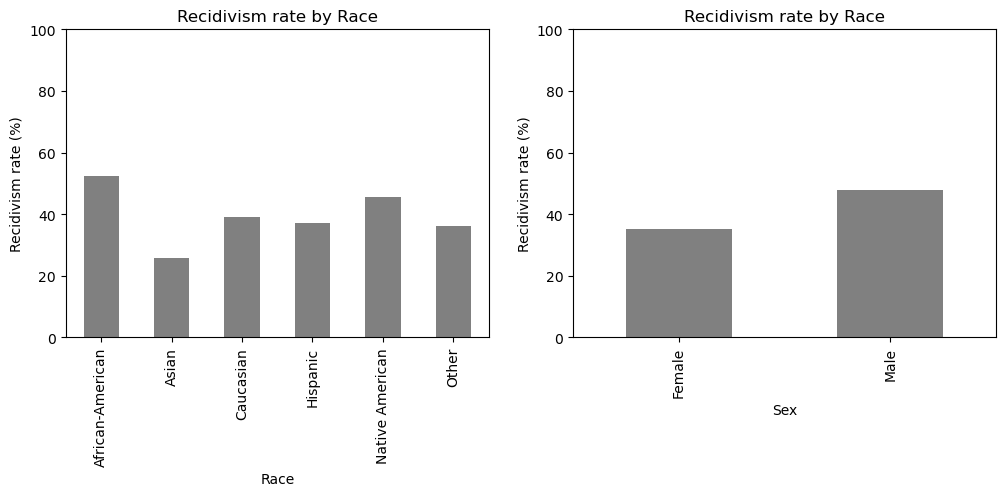

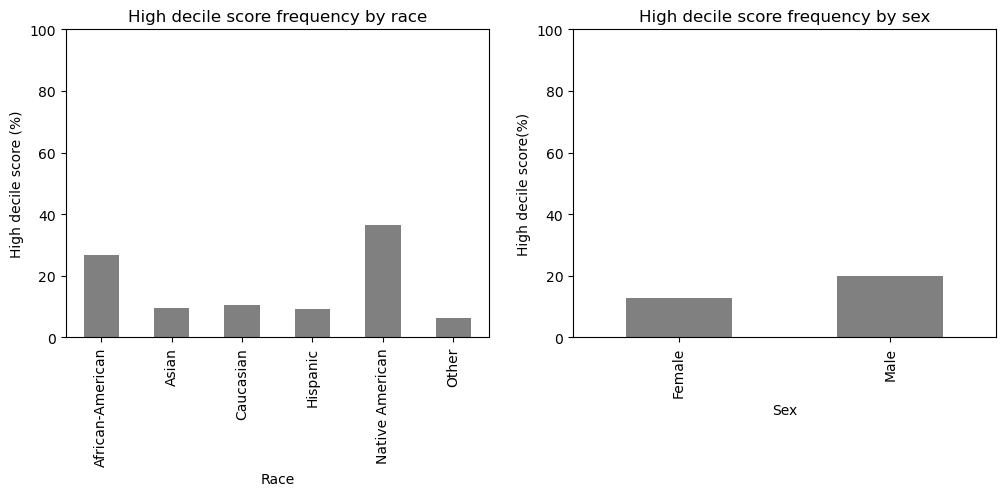

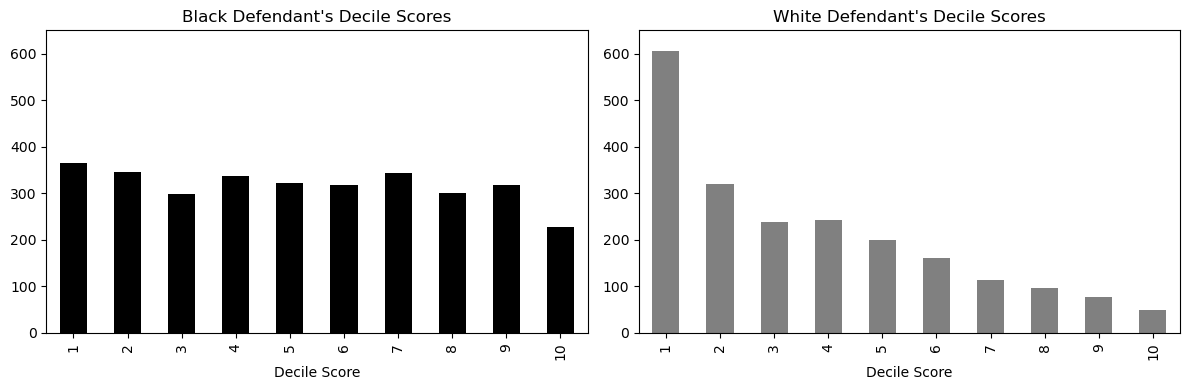

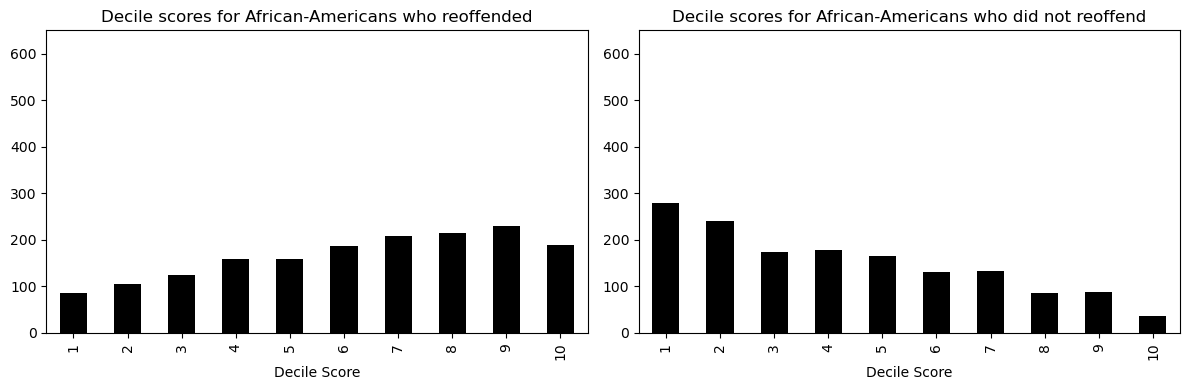

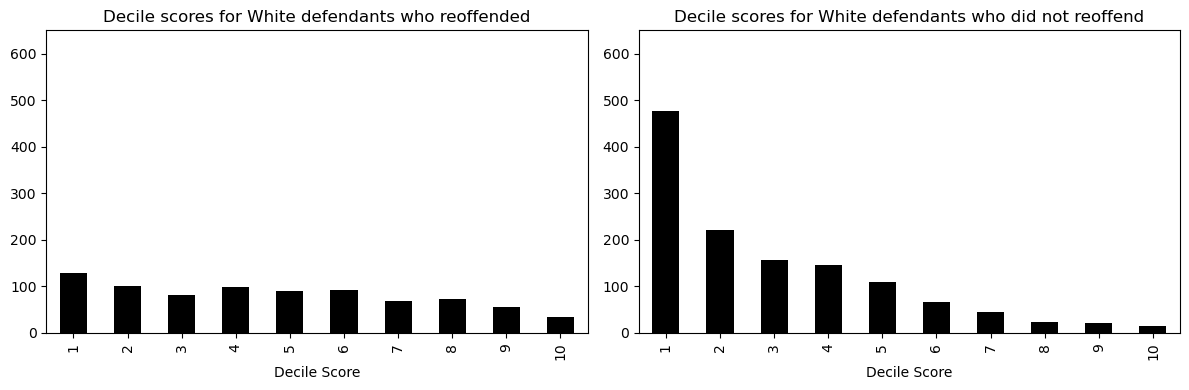

In [128]:


#hvor ofte ulike grupperinger av mennesker (kvinner, menn, hvite og svarte) gjentar forbrytelser

race_recidivism = df.groupby('race')['two_year_recid'].mean() * 100
sex_recidivism = df.groupby('sex')['two_year_recid'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

race_recidivism.plot(kind="bar", ax = axes[0], color = "grey")
axes[0].set_title("Recidivism rate by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Recidivism rate (%)")
axes[0].set_ylim(0, 100)

sex_recidivism.plot(kind="bar", ax = axes[1], color = "grey")
axes[1].set_title("Recidivism rate by Race")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Recidivism rate (%)")
axes[1].set_ylim(0, 100)

plt.show()


#hvor ofte ulike grupperinger av mennesker (kvinner, menn, hvite og svarte) blir predikert av algoritmen til å begå straffbare handlinger i framtiden.

df['score_binary'] = df['score_text'].map({
    'High': 1,
    'Medium': 0,
    'Low': 0
})
race_compass_prediction = df.groupby('race')['score_binary'].mean() * 100
sex_compass_prediction = df.groupby('sex')['score_binary'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

race_compass_prediction.plot(kind="bar", ax = axes[0], color = "grey")
axes[0].set_title("High decile score frequency by race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("High decile score (%)")
axes[0].set_ylim(0, 100)

sex_compass_prediction.plot(kind="bar", ax = axes[1], color = "grey")
axes[1].set_title("High decile score frequency by sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("High decile score(%)")
axes[1].set_ylim(0, 100)

plt.show()


#hvor ofte ulike grupper fikk ulike risikoskårer.


df_black = df[df['race'] == "African-American"]
df_white = df[df['race'] == "Caucasian"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#black defendants
df_black['decile_score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='black')
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

#White defendants
df_white['decile_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='gray')
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

#hvor ofte de som begikk nye straffbare hadlinger (og de som ikke gjorde det) fikk ulike risikoskårer, 
# og hvordan dette ser ut hvis du kun ser på hvite eller svarte.
df_black_recidivist = df_black[df_black["two_year_recid"] == 1]
df_black_non_recidivist = df_black[df_black["two_year_recid"] == 0]

df_white_recidivist = df_white[df_white["two_year_recid"] == 1]   
df_white_non_recidivist = df_white[df_white["two_year_recid"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_black_recidivist['decile_score'].value_counts().sort_index().plot(kind='bar', ax = axes[0], color='black')
axes[0].set_title("Decile scores for African-Americans who reoffended")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

df_black_non_recidivist['decile_score'].value_counts().sort_index().plot(kind='bar', ax = axes[1], color='black')
axes[1].set_title("Decile scores for African-Americans who did not reoffend")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_white_recidivist['decile_score'].value_counts().sort_index().plot(kind='bar', ax = axes[0], color='black')
axes[0].set_title("Decile scores for White defendants who reoffended")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

df_white_non_recidivist['decile_score'].value_counts().sort_index().plot(kind='bar', ax = axes[1], color='black')
axes[1].set_title("Decile scores for White defendants who did not reoffend")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()




b) Regner ut falske positive for Afroamerikanere og Hvite

 Vi endrer nå slik at både "medium" og "høy" decile score anses som høy risiko

In [145]:
#Her sier vi at medium og høy risiko anses som høy risiko
df['score_binary'] = df['score_text'].map({
    'High': 1,
    'Medium': 1,
    'Low': 0
})


#hele befolkningen

true_positive = 0; true_negative = 0; false_positive = 0 ;false_negative = 0

#for kvinner, menn, hvite, og svarte
true_positive_female, true_negative_female, false_positive_female, false_negative_female = 0,0,0,0
true_positive_male, true_negative_male,  false_positive_male, false_negative_male = 0,0,0,0
true_positive_white, true_negative_white, false_positive_white, false_negative_white = 0,0,0,0
true_positive_black, true_negative_black, false_positive_black, false_negative_black = 0,0,0,0

#tell true/false negative/positive

for i in range(len(df["score_binary"])):
    if df["score_binary"].iloc[i] == 1 and df["two_year_recid"].iloc[i] == 1:
        true_positive  += 1

        if df["sex"].iloc[i] == "Female":
            true_positive_female += 1
        else: 
            true_positive_male +=1
        if df["race"].iloc[i] == "Caucasian":
            true_positive_white += 1
        if df["race"].iloc[i] == "African-American":
            true_positive_black += 1


    if df["score_binary"].iloc[i] == 0 and df["two_year_recid"].iloc[i] == 0:
        true_negative += 1

        if df["sex"].iloc[i] == "Female":
            true_negative_female += 1
        else: 
            true_negative_male +=1
        if df["race"].iloc[i] == "Caucasian":
            true_negative_white += 1
        if df["race"].iloc[i] == "African-American":
            true_negative_black += 1


    if df["score_binary"].iloc[i] == 0 and df["two_year_recid"].iloc[i] == 1:
        false_negative += 1

        if df["sex"].iloc[i] == "Female":
            false_negative_female += 1
        else: 
            false_negative_male +=1
        if df["race"].iloc[i] == "Caucasian":
            false_negative_white += 1
        if df["race"].iloc[i] == "African-American":
            false_negative_black += 1

    if df["score_binary"].iloc[i] == 1 and df["two_year_recid"].iloc[i] == 0:
        false_positive += 1

        if df["sex"].iloc[i] == "Female":
            false_positive_female += 1
        else: 
            false_positive_male +=1
        if df["race"].iloc[i] == "Caucasian":
            false_positive_white += 1
        if df["race"].iloc[i] == "African-American":
            false_positive_black += 1
    
#rate
false_positive_rate = false_positive / (df["two_year_recid"] == 0).sum()
false_negative_rate = false_negative /(df["score_binary"]== 1).sum()
true_positive_rate = true_positive /  len(df["score_binary"])
true_negative_rate = true_negative /  len(df["score_binary"])

#Female
female_true_positive_rate = true_positive_female / (df["sex"] == "Female").sum()
female_true_negative_rate = true_negative_female / (df["sex"] == "Female").sum()
female_false_positive_rate = false_positive_female / (df["sex"] == "Female").sum()
female_false_negative_rate = false_negative_female / (df["sex"] == "Female").sum()

#Male
male_true_positive_rate = true_positive_male / (df["sex"] == "Male").sum()
male_true_negative_rate = true_negative_male / (df["sex"] == "Male").sum()
male_false_positive_rate = false_positive_male / (df["sex"] == "Male").sum()
male_false_negative_rate = false_negative_male / (df["sex"] == "Male").sum()

#white
white_true_positive_rate = true_positive_white / (df["race"] == "Caucasian").sum()
white_true_negative_rate = true_negative_white / (df["race"] == "Caucasian").sum()
white_false_positive_rate = false_positive_white / ((df["race"] == "Caucasian") & (df["two_year_recid"] == 0)).sum()
white_false_negative_rate = false_negative_white / ((df["race"] == "Caucasian")  & (df["two_year_recid"] == 1)).sum()

#black
black_true_positive_rate = true_positive_black / ((df["race"] == "African-American")) .sum()
black_true_negative_rate = true_negative_black / ((df["race"] == "African-American")).sum()
black_false_positive_rate = false_positive_black / ((df["race"] == "African-American") & (df["two_year_recid"] == 0)).sum()
black_false_negative_rate = false_negative_black / ((df["race"] == "African-American") & (df["two_year_recid"] == 1)).sum()

print("Black false postive rate: ", black_false_positive_rate)
print("White false positive rate: ", white_false_positive_rate)




Black false postive rate:  0.4233817701453104
White false positive rate:  0.22014051522248243


c) Bayes setning 
 
Sannsynligheten for at du er svart dersom det har blitt falsk positiv 

62% av alle som blir feilklassifiserte er Afro-Amerikanere

Altså er distribusjonen av feilklassifiseringer uproporsjonal med befolkningen når det er 51% afroamerikanere i datasettet, 
men 62% av falske positive er afroamerikanere

In [130]:

p_black = (df["race"] == "African-American").sum() / len(df)
print(p_black)

#Anvender bayes setning:

p_black_given_false_positive = (black_false_positive_rate * p_black)/false_positive_rate


print("Av alle falske positive, hvor mange er Afro-amerikanere? :", p_black_given_false_positive *100, "%" )
print("Antall afroamerikanere i datasettet: ", p_black*100, "%")

0.5144199611147116
Av alle falske positive, hvor mange er Afro-amerikanere? : 62.96660117878192 %
Antall afroamerikanere i datasettet:  51.441996111471155 %


d) 

In [141]:
X = df[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid"]]
categorical_cols = ["age_cat", "race", "sex", "c_charge_degree"]
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X = X.drop(["age_cat_25 - 45", "race_Caucasian", "sex_Male", "c_charge_degree_F"], axis=1)
Y = df["score_text"] != "Low"

X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state = 42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
compass_accuracy = accuracy_score(y_test, y_pred)



b = model.intercept_[0]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


control = sigmoid( b )
coefs = dict(zip(X.columns, model.coef_[0]))

racialBias = np.exp( coefs["race_African-American"] ) / (1 - control + (control * np.exp(coefs["race_African-American"])))

print("Racial Bias: ", racialBias)

Racial Bias:  1.491533138544787


e) Trener en random forest modell uten etnisitet som predikator

Her ser dere false positive/negative rates av Caucasians, African-Americans, Males, Females

Og feature importances, som er et mål på hvor viktige de ulike forklaringsvariablene er i klassifiseringsbeslutningen. 

Vi ser også accuracy score, som ligger på rundt 75% med tredybde = 10


Modellen uten rase som predikator gir fortsatt over gjennomsnittet høy false positive rate for Afroamerikanere, og lav false positive rate til Hvite. Dette tyder på at modellen fortsatt er urettferdig for Afroamerikanere. Dette kan grunnes systemiske forskjeller. For eksempel kan Afroamerikanere i gjennomsnitt få hardere dommer for den samme forbrytelsen. Ettersom "charge degree"  er en forklaringsvariabel kan den fungere som proxy for etnisitet. Det samme kan gjelde for antall tidligere forbrytelser - altså at Afroamerikanere i gjennomsnitt har større sannsynlighet for å bli dømt for kriminelle handlinger.

COMPASS og RandomForest modellene får nesten lik accuracy på rundt 75%

Accuracy score i Random Forest modellen:  0.7447
Accuracy score i COMPASS modellen:  0.7518
False positive rate in our new model: 0.16881594372801875 %
False negative rate in our new model: 0.36231884057971014 %
False positive rate for African-Americans: 0.25609756097560976 %
False negative rate for African-Americans: 0.3185840707964602 %
False positive rate for Caucasians: 0.10326086956521739 %
False negative rate for Caucasians: 0.4581005586592179 %
False positive rate for Males: 0.18168389955686853 %
False negative rate for Males: 0.3298611111111111 %
False positive rate for Females: 0.11931818181818182 %
False negative rate for Females: 0.5263157894736842 %
FEATURE IMPORTANCES: 


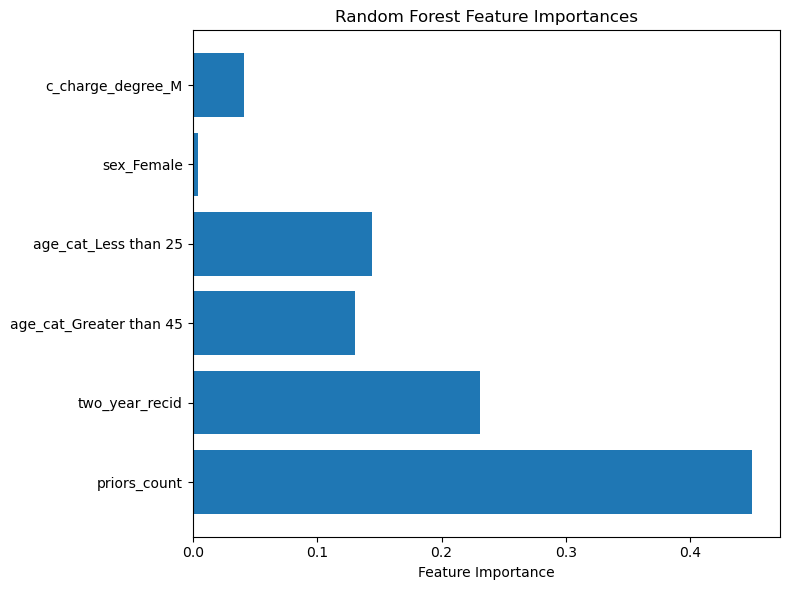

In [140]:
X_new = df[["age_cat", "sex", "priors_count", "c_charge_degree", "two_year_recid"]]
categorical_cols = ["age_cat", "sex", "c_charge_degree"]
X_new = pd.get_dummies(X_new, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X_new = X_new.drop(["age_cat_25 - 45", "sex_Male", "c_charge_degree_F"], axis=1)
Y = df["score_text"] != "Low"

X_train, X_test, y_train, y_test = train_test_split(X_new,Y, random_state = 42)

clf = RandomForestClassifier(n_estimators=1000, max_depth=4)
clf = clf.fit(X_train, y_train)
#Accuracy
y_pred = clf.predict(X_test)
print("Accuracy score i Random Forest modellen: ", np.round(accuracy_score(y_test, y_pred), 4))
print("Accuracy score i COMPASS modellen: ",  np.round(compass_accuracy, 4))

#Beregner false positive rates for hvite og svarte
test_meta = df.loc[X_test.index]

subset1 = (test_meta["race"] == "African-American")
subset2 = (test_meta["race"] == "Caucasian")

y_test_black = y_test[subset1]
y_pred_black = y_pred[subset1]

y_test_white = y_test[subset2]
y_pred_white = y_pred[subset2]

y_test_male = y_test[test_meta["sex"] == "Male"]
y_pred_male = y_pred[test_meta["sex"] == "Male"]

y_test_female = y_test[test_meta["sex"] == "Female"]
y_pred_female = y_pred[test_meta["sex"] == "Female"]

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("False positive rate in our new model:", fpr, "%")
print("False negative rate in our new model:", fnr, "%")

#fnr and fpr for African-Americans
tn, fp, fn, tp = confusion_matrix(y_test_black, y_pred_black).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print("False positive rate for African-Americans:", fpr, "%")
print("False negative rate for African-Americans:", fnr, "%")
#fnr and fpr for Caucasians
tn, fp, fn, tp = confusion_matrix(y_test_white, y_pred_white).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print("False positive rate for Caucasians:", fpr, "%")
print("False negative rate for Caucasians:", fnr, "%")
#fnr and fpr for Males
tn, fp, fn, tp = confusion_matrix(y_test_male, y_pred_male).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print("False positive rate for Males:", fpr, "%")
print("False negative rate for Males:", fnr, "%")
#fnr and fpr for Females
tn, fp, fn, tp = confusion_matrix(y_test_female, y_pred_female).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print("False positive rate for Females:", fpr, "%")
print("False negative rate for Females:", fnr, "%")


#Feature importance
importances = clf.feature_importances_

print("FEATURE IMPORTANCES: ")

plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances)
plt.yticks(range(len(importances)), X_new.columns)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()




